# Name: Isha Santosh Awate
# Module Name: Modelling and Optimisation Under Uncertainty
# Module Code: 7135CEM
# ID Number:16298107
# Title:Prediction of Air Quality Utilising Gaussian Process Regression and Classification: An In-Depth Examination of Carbon Monoxide Behaviour in Urban Settings

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    RationalQuadratic,
    ConstantKernel as C
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ----------------------------------------------------------------------
# A0. SETUP: PATHS & OUTPUT FOLDER
# ----------------------------------------------------------------------

# Path to the dataset (relative to this script)
DATA_PATH = os.path.join("data", "AirQualityUCI.csv")

# Folder for saving figures
FIGS_DIR = "figs"
os.makedirs(FIGS_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# Task 1 A1. DATA LOADING AND PREPROCESSING
# ----------------------------------------------------------------------

print("=== A1. Loading and preprocessing data ===")

# Load dataset from UCI (semicolon separator, comma decimal, -200 as missing)
df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    na_values=[-200]
)

# Drop unnamed trailing columns (common in this dataset)
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("Unnamed")]

# Parse DateTime properly (format: dd/mm/yyyy hh.mm.ss)
df_raw["DateTime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Sort chronologically and drop rows where DateTime is NaT
df_raw = df_raw.sort_values("DateTime")
df_raw = df_raw.dropna(subset=["DateTime"])

# Feature and target definitions
feature_cols = ["T", "RH", "AH", "NO2(GT)", "C6H6(GT)"]
target_col = "CO(GT)"

# Add hour-of-day as an engineered feature
df_raw["Hour"] = df_raw["DateTime"].dt.hour
feature_cols_with_hour = feature_cols + ["Hour"]

# Only drop rows where the TARGET is missing
df = df_raw.dropna(subset=[target_col]).copy()

# Forward-fill then backward-fill for feature columns (new pandas style: ffill() / bfill())
df[feature_cols_with_hour] = df[feature_cols_with_hour].ffill().bfill()

# Extract X and y
X = df[feature_cols_with_hour].values
y = df[target_col].values

# Chronological train-test split (80/20)
n = len(df)
train_size = int(0.8 * n)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Total samples after cleaning: {n}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------------------
# Task1.2 A2. BASELINE REGRESSION MODELS (LINEAR REGRESSION & RANDOM FOREST)
# ----------------------------------------------------------------------

print("\n=== A2. Baseline regression models ===")

baseline_results = {}


def evaluate_regression_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit regression model and compute RMSE, MAE, R²."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)

    baseline_results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n{name} Results:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R²  : {r2:.4f}")

    return y_pred


# Linear Regression baseline
lin_reg = LinearRegression()
y_pred_lin = evaluate_regression_model(
    "Linear Regression",
    lin_reg,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

# Random Forest Regression baseline
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
y_pred_rf = evaluate_regression_model(
    "Random Forest Regression",
    rf_reg,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
)

# ----------------------------------------------------------------------
# Task 1.3 A3. GAUSSIAN PROCESS REGRESSION (KERNEL COMPARISON)
# ----------------------------------------------------------------------

print("\n=== A3. Gaussian Process Regression with multiple kernels ===")

gp_results = {}
gp_predictions = {}
gp_std_devs = {}

kernels = {
    "RBF": C(1.0) * RBF(length_scale=1.0),
    "Matern_3_2": C(1.0) * Matern(length_scale=1.0, nu=1.5),
    "RationalQuadratic": C(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0),
}

for name, kernel in kernels.items():
    print(f"\nTraining GPR with {name} kernel...")
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.1,          # noise term (variance)
        normalize_y=True,
        random_state=42
    )

    gpr.fit(X_train_scaled, y_train)
    y_mean, y_std = gpr.predict(X_test_scaled, return_std=True)

    rmse = np.sqrt(mean_squared_error(y_test, y_mean))
    mae = mean_absolute_error(y_test, y_mean)
    r2 = r2_score(y_test, y_mean)
    lml = gpr.log_marginal_likelihood_value_

    gp_results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "LML": lml
    }
    gp_predictions[name] = y_mean
    gp_std_devs[name] = y_std

    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R²  : {r2:.4f}")
    print(f"  LML : {lml:.2f}")
    print(f"  Optimised kernel: {gpr.kernel_}")

# ----------------------------------------------------------------------
# Task 1.4 A4. BINARY CLASSIFICATION: GAUSSIAN PROCESS + RANDOM FOREST
# ----------------------------------------------------------------------

print("\n=== A4. Gaussian Process Classification (Low vs High CO) ===")

# Create binary labels: 1 = high CO, 0 = low CO
threshold = 1.0
y_binary = (y >= threshold).astype(int)

y_train_bin = y_binary[:train_size]
y_test_bin = y_binary[train_size:]

# Gaussian Process Classifier (Matérn 3/2 kernel)
gpc_kernel = C(1.0) * Matern(length_scale=1.0, nu=1.5)
gpc = GaussianProcessClassifier(kernel=gpc_kernel, random_state=42, max_iter_predict=100)

print("Training Gaussian Process Classifier...")
gpc.fit(X_train_scaled, y_train_bin)
y_pred_gpc = gpc.predict(X_test_scaled)
y_proba_gpc = gpc.predict_proba(X_test_scaled)[:, 1]

acc_gpc = accuracy_score(y_test_bin, y_pred_gpc)
prec_gpc = precision_score(y_test_bin, y_pred_gpc)
rec_gpc = recall_score(y_test_bin, y_pred_gpc)
f1_gpc = f1_score(y_test_bin, y_pred_gpc)

print("\nGaussian Process Classification Results:")
print(f"  Accuracy : {acc_gpc:.4f}")
print(f"  Precision: {prec_gpc:.4f}")
print(f"  Recall   : {rec_gpc:.4f}")
print(f"  F1-score : {f1_gpc:.4f}")
print("\nClassification Report (GPC):")
print(classification_report(y_test_bin, y_pred_gpc, target_names=["Low CO", "High CO"]))

# Random Forest Classifier baseline
print("\nTraining Random Forest Classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_scaled, y_train_bin)
y_pred_rf_clf = rf_clf.predict(X_test_scaled)
y_proba_rf_clf = rf_clf.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test_bin, y_pred_rf_clf)
prec_rf = precision_score(y_test_bin, y_pred_rf_clf)
rec_rf = recall_score(y_test_bin, y_pred_rf_clf)
f1_rf = f1_score(y_test_bin, y_pred_rf_clf)

print("\nRandom Forest Classification Results:")
print(f"  Accuracy : {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall   : {rec_rf:.4f}")
print(f"  F1-score : {f1_rf:.4f}")
print("\nClassification Report (RF):")
print(classification_report(y_test_bin, y_pred_rf_clf, target_names=["Low CO", "High CO"]))

cm_gpc = confusion_matrix(y_test_bin, y_pred_gpc)

# ----------------------------------------------------------------------
# Task 1.5 A5. FIGURE GENERATION (ALL FIGURES SAVED TO figs/)
# ----------------------------------------------------------------------

print("\n=== A5. Generating and saving figures ===")

# Figure 1: True vs Predicted CO with uncertainty (best GP kernel)
best_kernel_name = "Matern_3_2"
y_pred_best = gp_predictions[best_kernel_name]
y_std_best = gp_std_devs[best_kernel_name]

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="True CO", linewidth=1)
plt.plot(y_pred_best, label=f"GP {best_kernel_name} mean", linewidth=1)
plt.fill_between(
    np.arange(len(y_pred_best)),
    y_pred_best - 2 * y_std_best,
    y_pred_best + 2 * y_std_best,
    alpha=0.2,
    label="±2σ"
)
plt.xlabel("Test sample index")
plt.ylabel("CO (mg/m³)")
plt.title("Figure 1: GP Regression – True vs Predicted CO")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "figure1_gp_regression.png"), dpi=300)
plt.close()

# Figure 2: RMSE comparison bar chart
all_model_names = list(baseline_results.keys()) + list(gp_results.keys())
rmse_values = [baseline_results[m]["RMSE"] for m in baseline_results] + \
              [gp_results[m]["RMSE"] for m in gp_results]

plt.figure(figsize=(8, 5))
plt.bar(all_model_names, rmse_values)
plt.ylabel("RMSE")
plt.title("Figure 2: RMSE Comparison – Baselines vs GP Kernels")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "figure2_rmse_comparison.png"), dpi=300)
plt.close()

# Figure 3: Confusion matrix for GPC
plt.figure(figsize=(4, 4))
plt.imshow(cm_gpc, interpolation="nearest", cmap="Blues")
plt.title("Figure 3: Confusion Matrix – GP Classifier")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Low CO", "High CO"], rotation=45)
plt.yticks(tick_marks, ["Low CO", "High CO"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_gpc[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "figure3_gpc_confusion.png"), dpi=300)
plt.close()

# Figure 4: Probability scatter for GPC
plt.figure(figsize=(6, 4))
jitter = np.random.normal(0, 0.02, size=len(y_test_bin))
plt.scatter(y_proba_gpc, y_test_bin + jitter, alpha=0.3)
plt.xlabel("Predicted probability of High CO (GPC)")
plt.ylabel("True label (jittered)")
plt.title("Figure 4: GPC Probability vs True Labels")
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "figure4_gpc_probability.png"), dpi=300)
plt.close()

print(f"\nAll done. Figures saved in folder: {FIGS_DIR}")
print("You can now use these results and figures in your report.")


=== A1. Loading and preprocessing data ===
Total samples after cleaning: 7674
Train samples: 6139, Test samples: 1535

=== A2. Baseline regression models ===

Linear Regression Results:
  RMSE: 0.6270
  MAE : 0.3798
  R²  : 0.7825

Random Forest Regression Results:
  RMSE: 0.6667
  MAE : 0.4184
  R²  : 0.7541

=== A3. Gaussian Process Regression with multiple kernels ===

Training GPR with RBF kernel...
  RMSE: 0.8378
  MAE : 0.5185
  R²  : 0.6117
  LML : -1202.61
  Optimised kernel: 1.16**2 * RBF(length_scale=1.44)

Training GPR with Matern_3_2 kernel...
  RMSE: 0.7779
  MAE : 0.4759
  R²  : 0.6652
  LML : -1098.67
  Optimised kernel: 1.9**2 * Matern(length_scale=4.8, nu=1.5)

Training GPR with RationalQuadratic kernel...
  RMSE: 0.7445
  MAE : 0.4707
  R²  : 0.6934
  LML : -1085.55
  Optimised kernel: 3.74**2 * RationalQuadratic(alpha=0.0267, length_scale=6.56)

=== A4. Gaussian Process Classification (Low vs High CO) ===
Training Gaussian Process Classifier...

Gaussian Process Clas

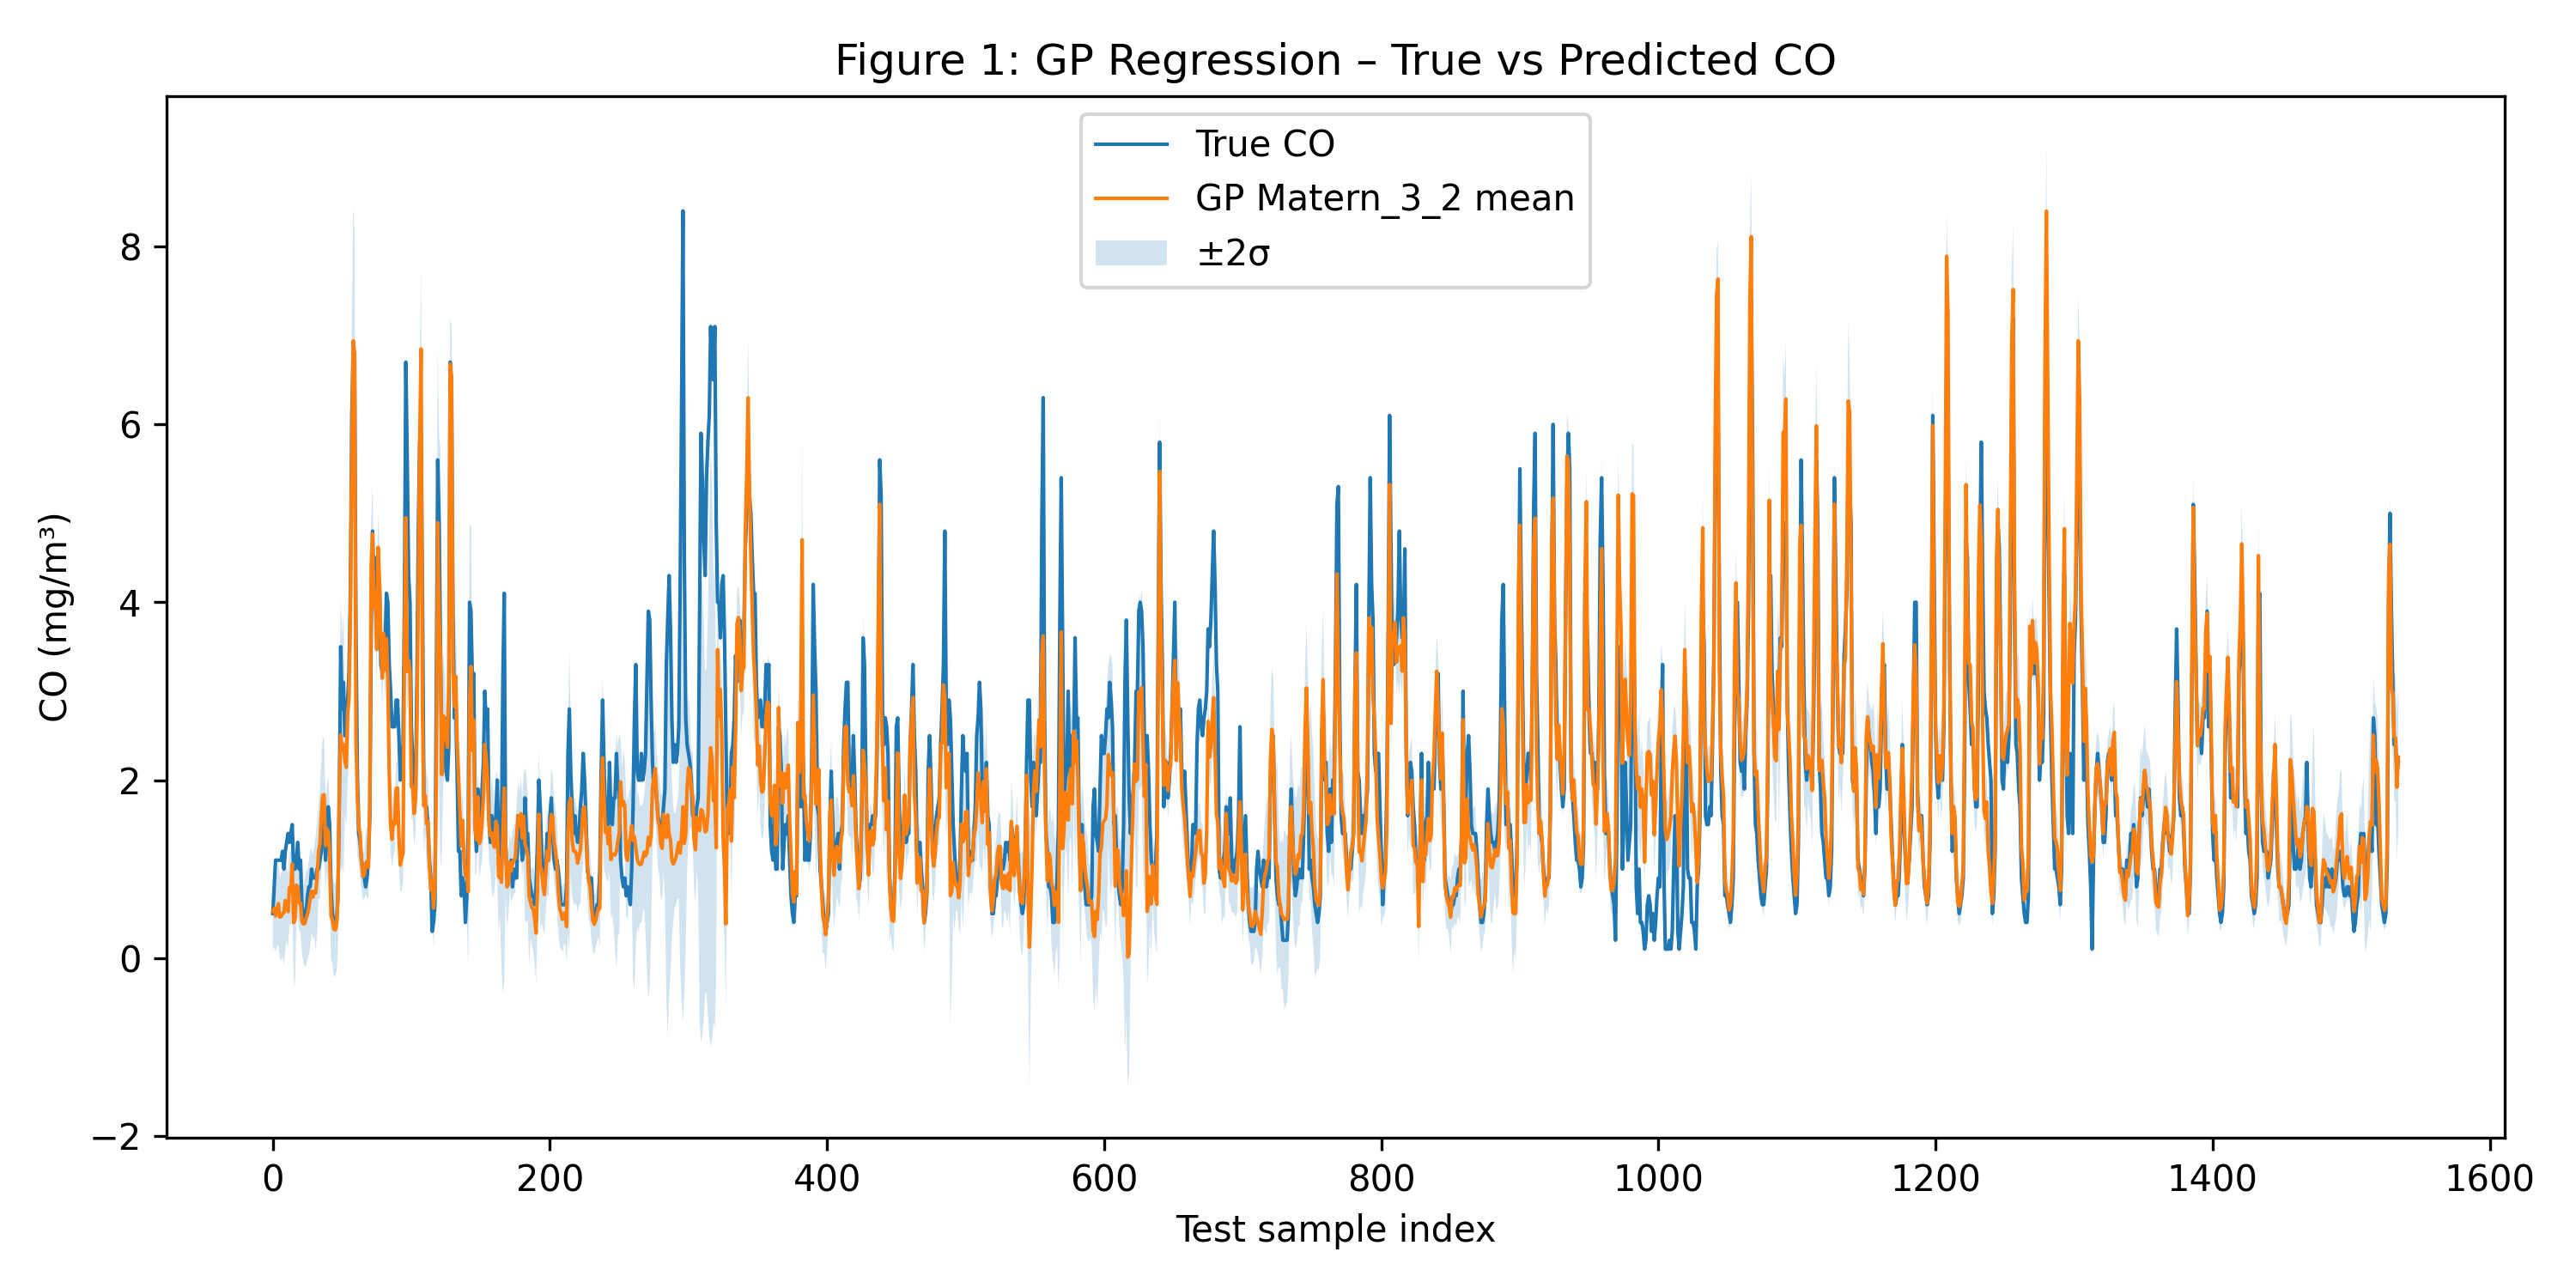

In [14]:
from IPython.display import Image
Image(filename="figs/figure1_gp_regression.png")


In [15]:
os.listdir("figs")


['figure1_gp_regression.png',
 'figure3_gpc_confusion.png',
 'figure2_rmse_comparison.png',
 'figure4_gpc_probability.png']

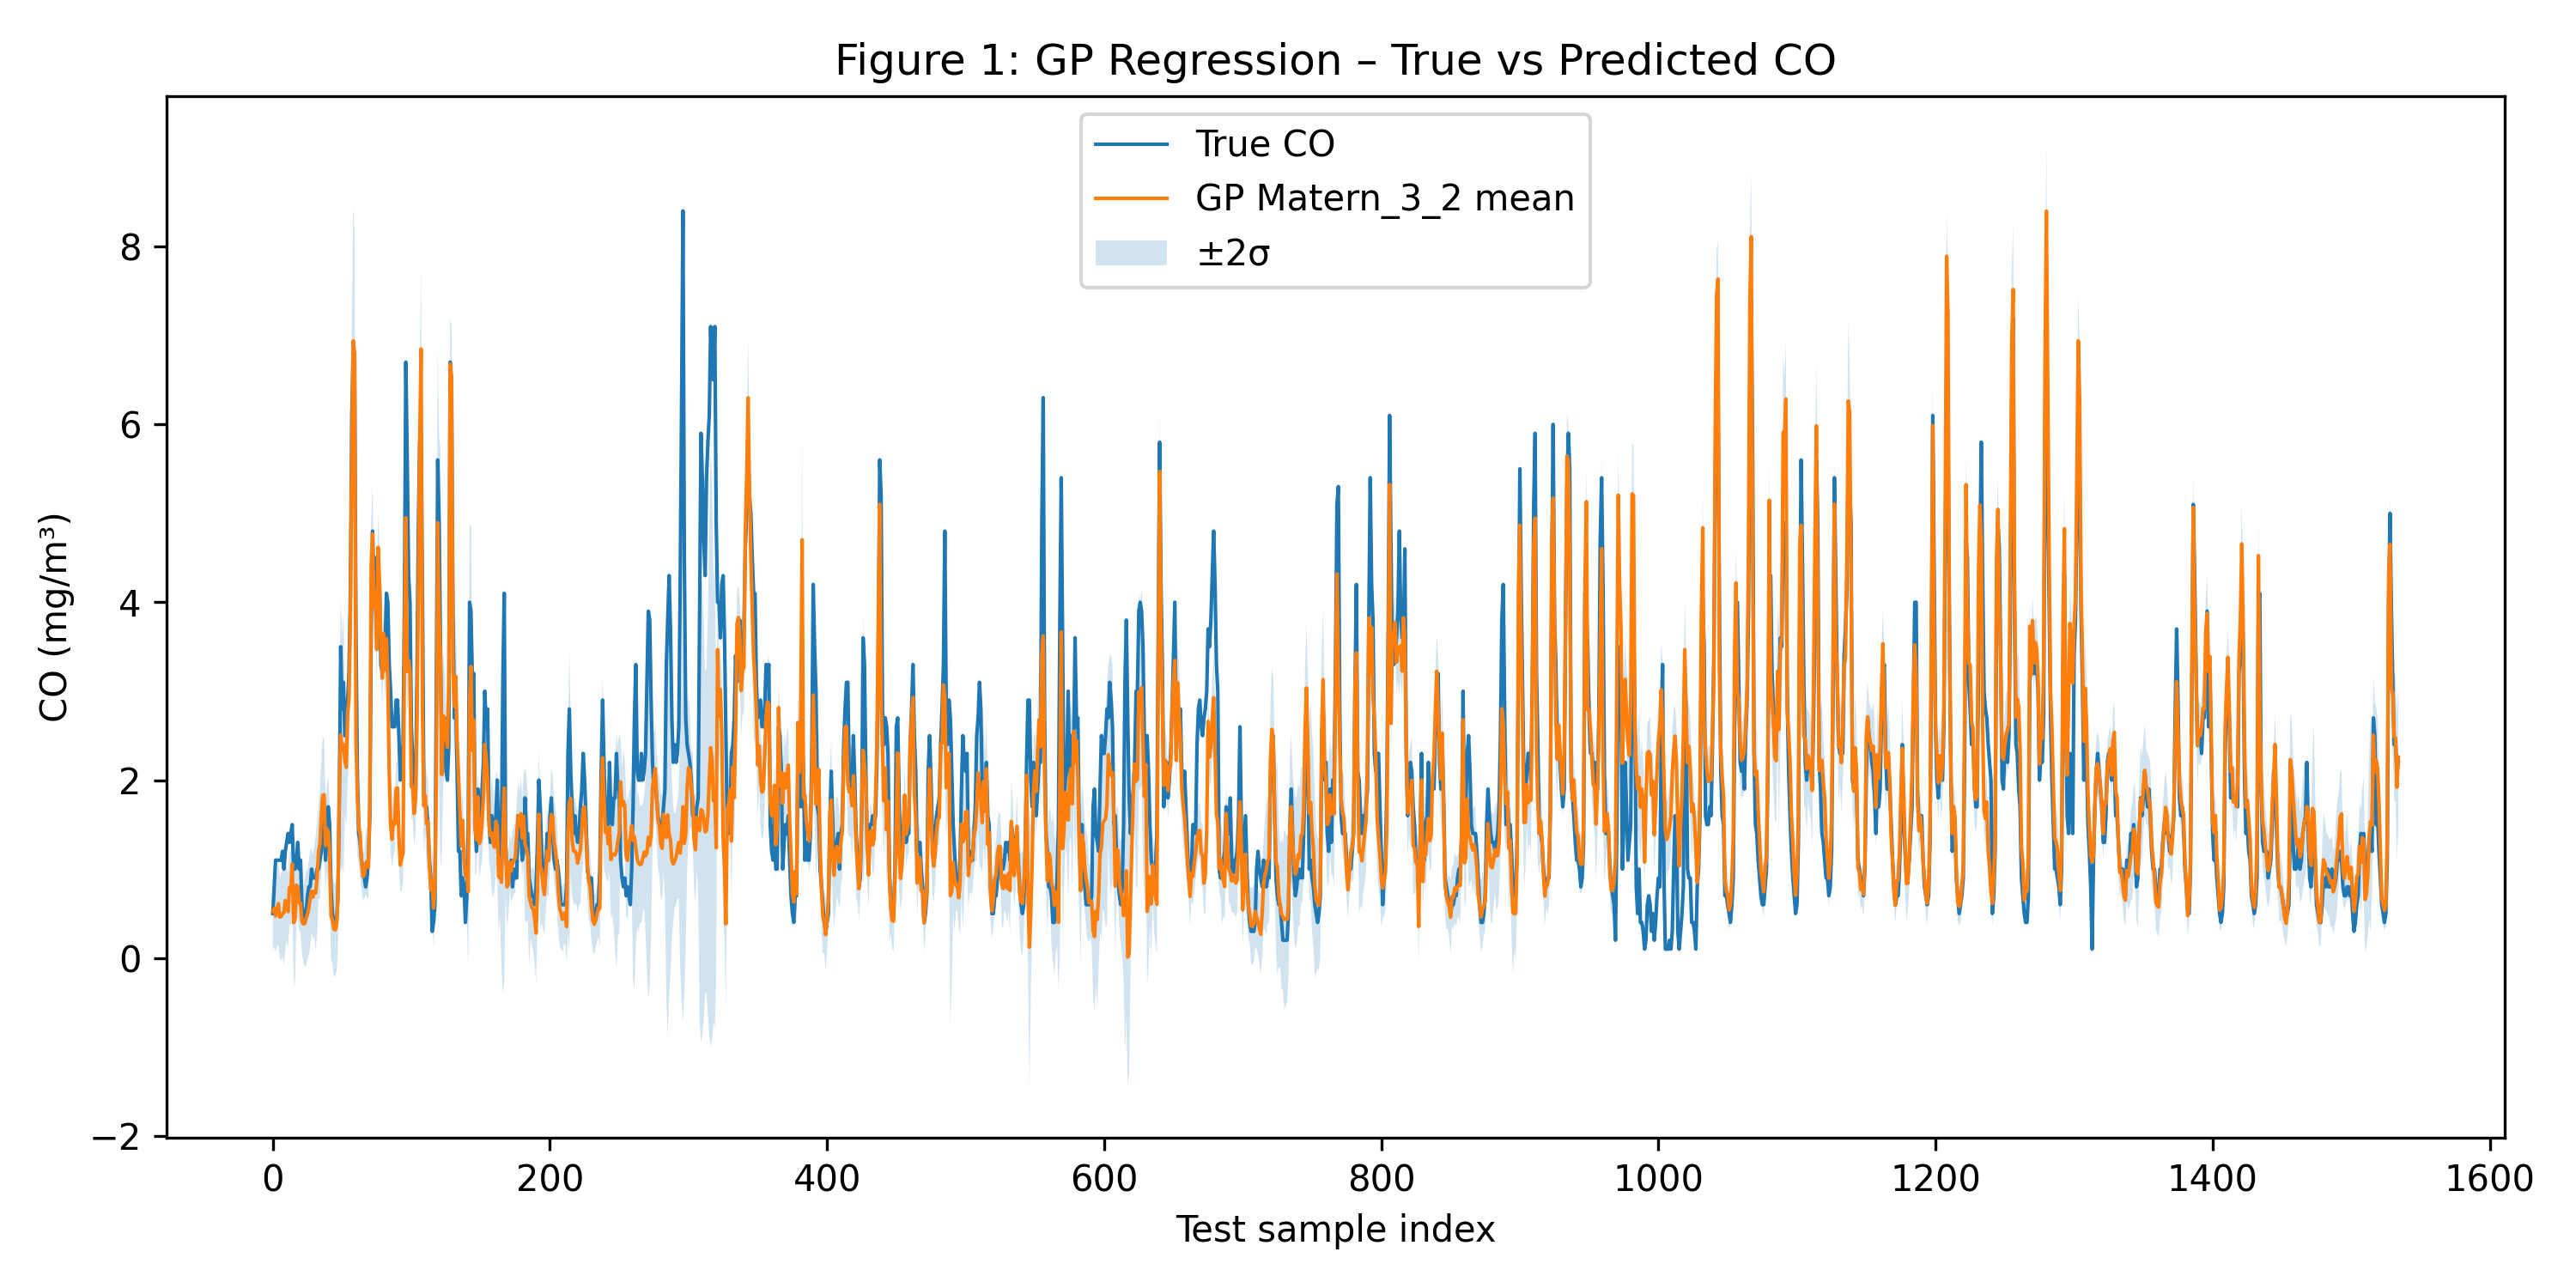

In [16]:
from IPython.display import Image
Image(filename="figs/figure1_gp_regression.png")


Figure 2:

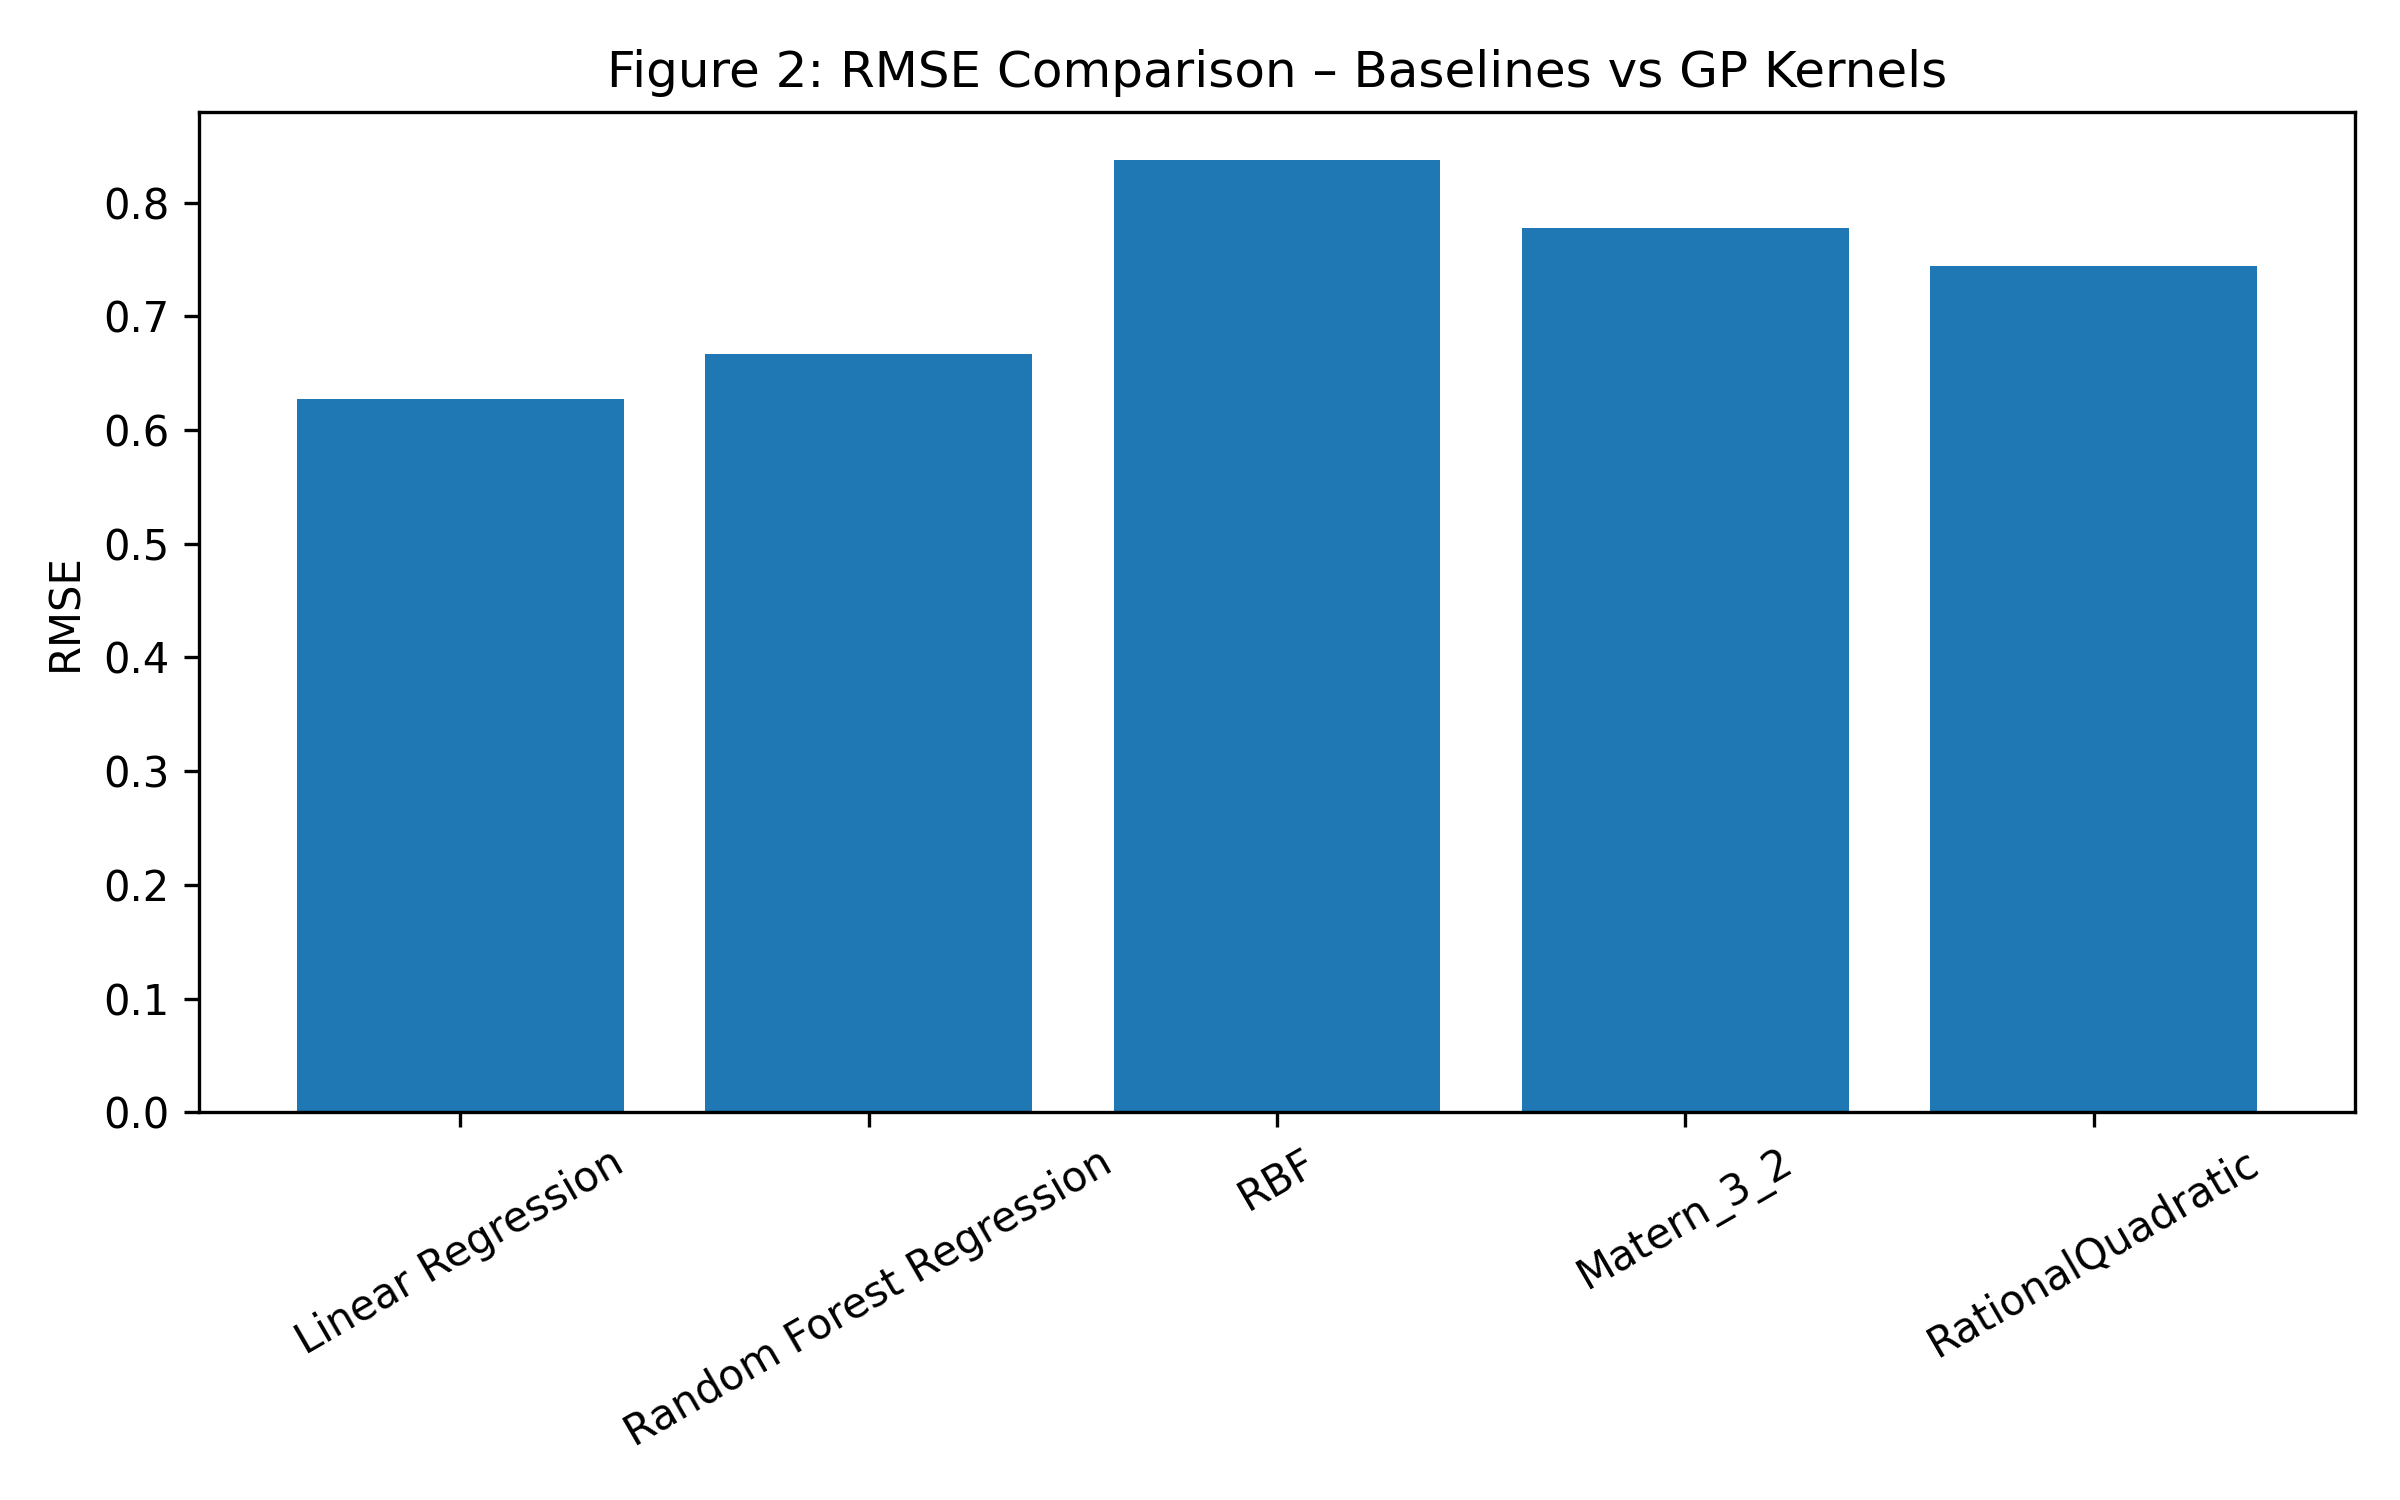

In [17]:
Image(filename="figs/figure2_rmse_comparison.png")


Figure 3:

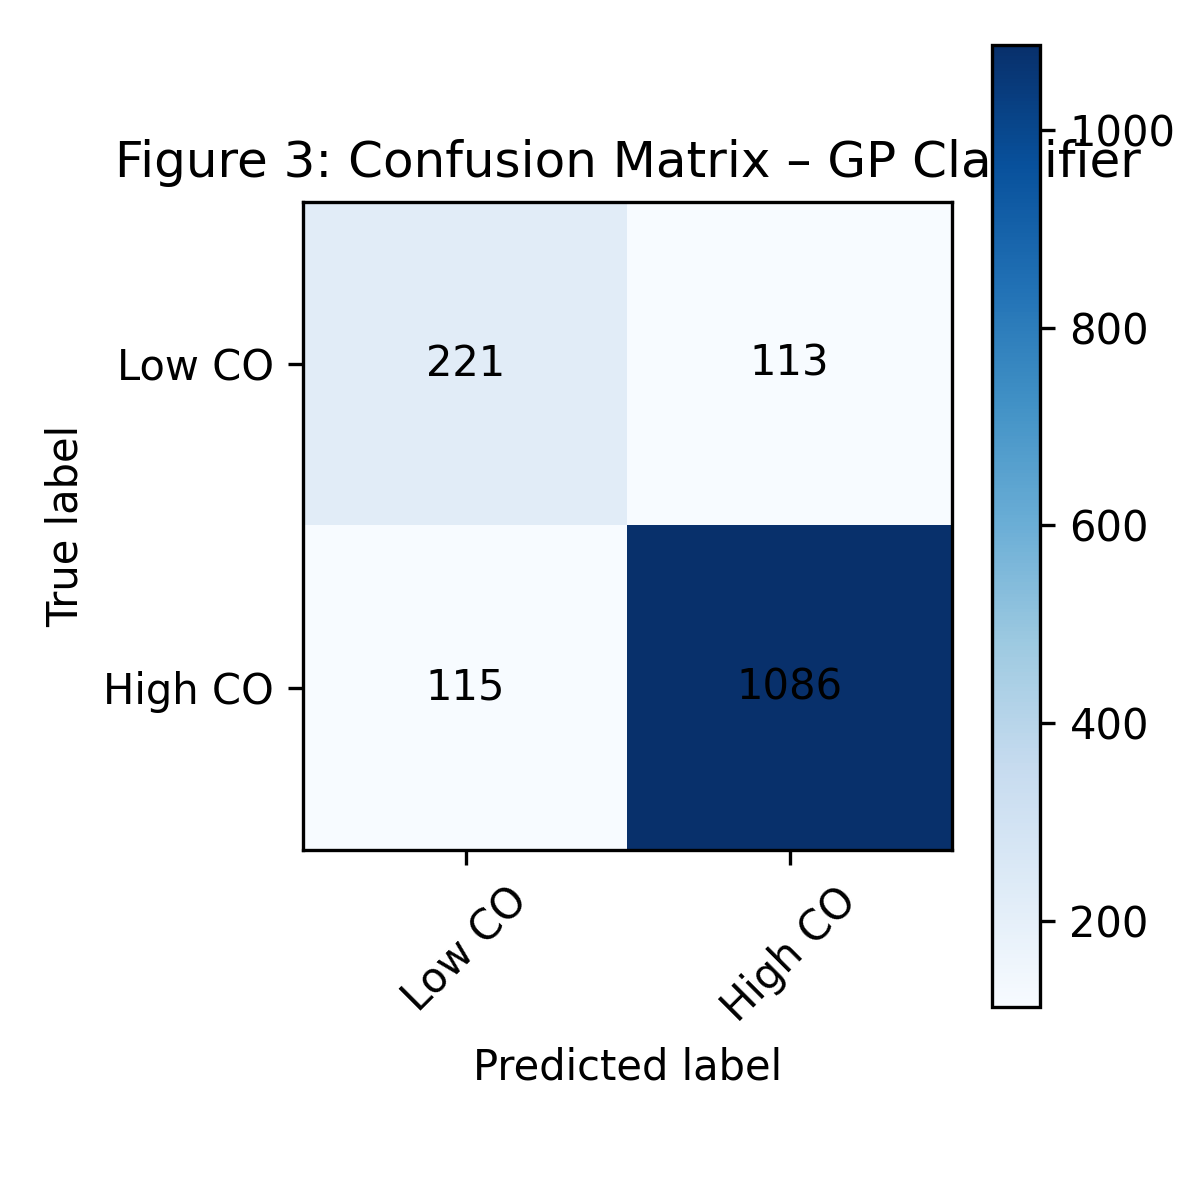

In [18]:
Image(filename="figs/figure3_gpc_confusion.png")


Figure 4:

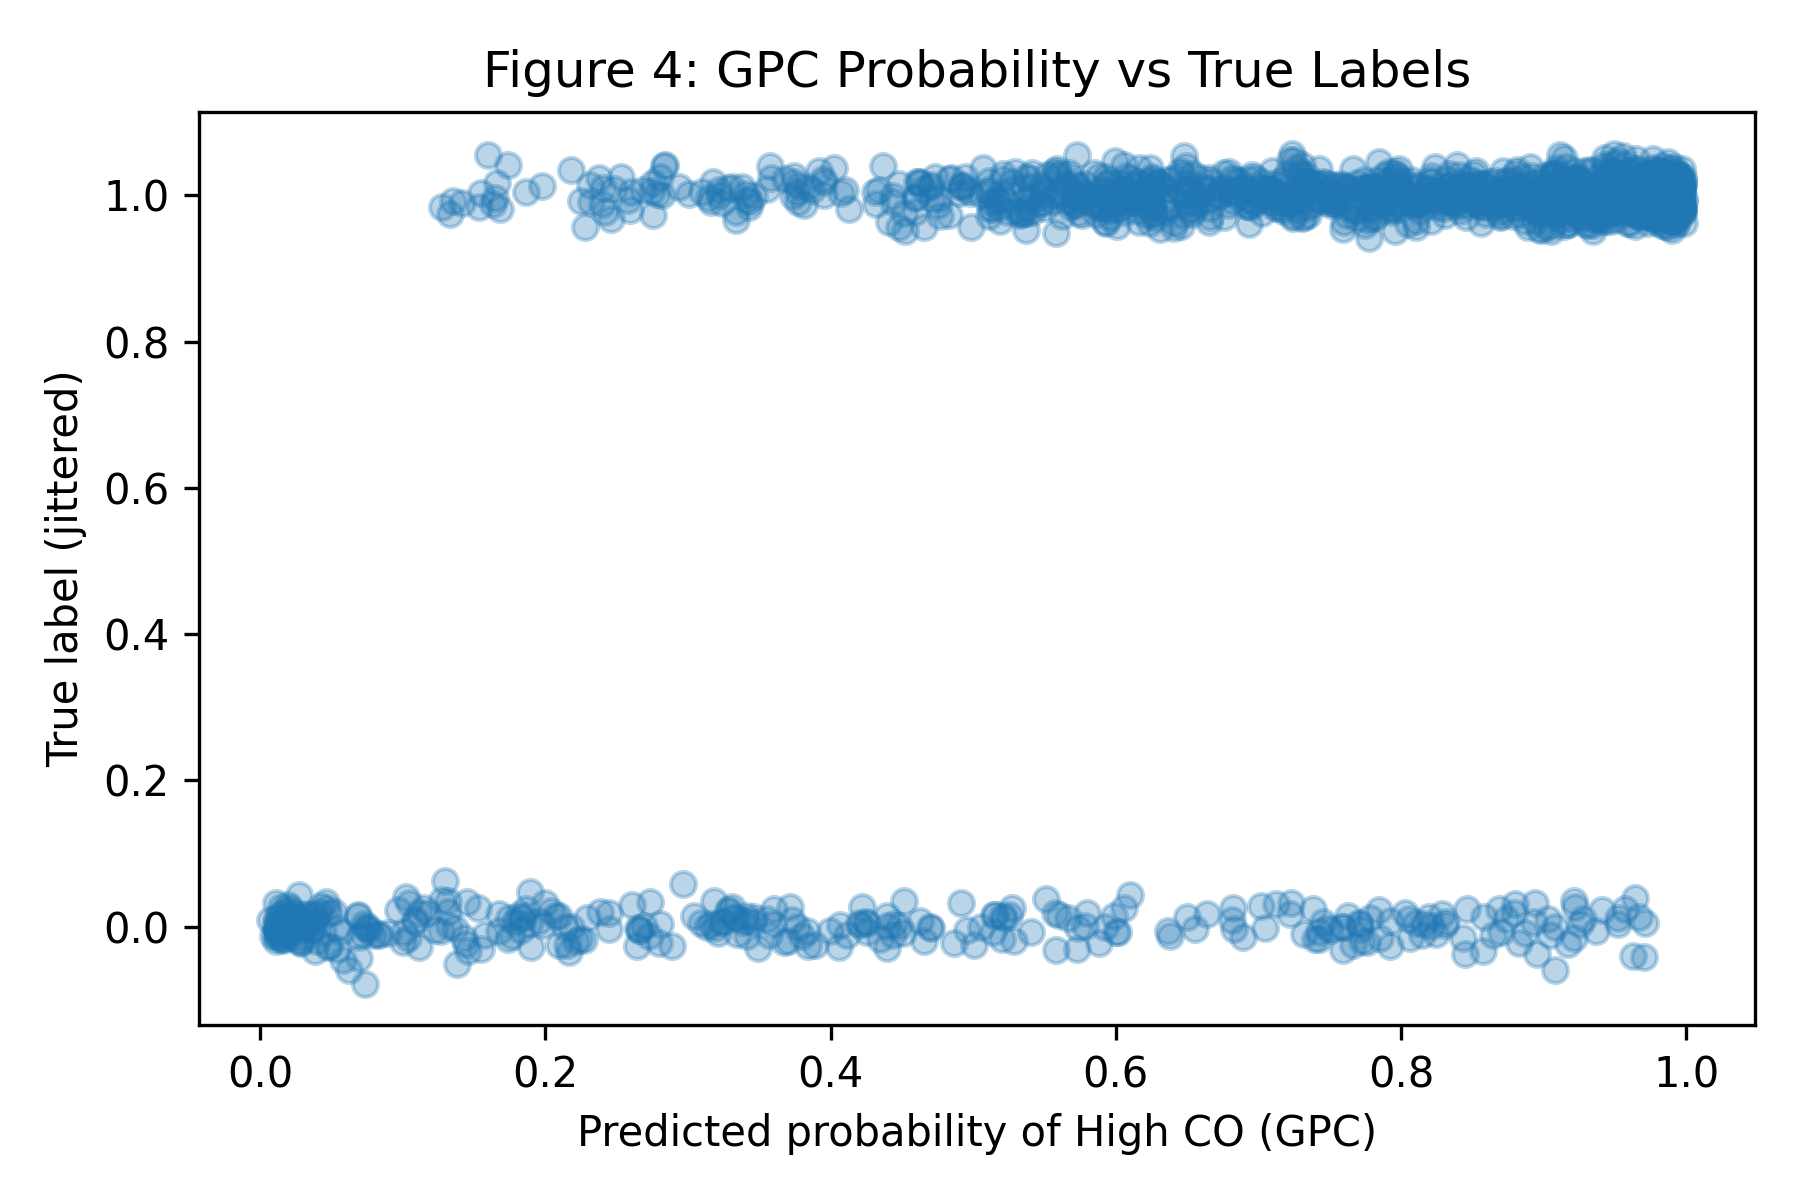

In [19]:
Image(filename="figs/figure4_gpc_probability.png")


In [3]:
# ============================================================
# TASK 2: EVOLUTIONARY AND FUZZY SYSTEMS
# Fuzzy Logic Controller (FLC) for an Assistive Smart Room
# ============================================================
# Controls ambient temperature and lighting for a disabled user
# ============================================================

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ------------------------------------------------------------
# TASK 2.1 — Define Fuzzy Input Variables
# ------------------------------------------------------------

temperature = ctrl.Antecedent(np.arange(0, 41, 1), 'temperature')  # °C
light_level = ctrl.Antecedent(np.arange(0, 101, 1), 'light_level') # %

# ------------------------------------------------------------
# TASK 2.2 — Define Fuzzy Output Variables
# ------------------------------------------------------------

heater_power = ctrl.Consequent(np.arange(0, 101, 1), 'heater_power') # %
lamp_brightness = ctrl.Consequent(np.arange(0, 101, 1), 'lamp_brightness') # %

# ------------------------------------------------------------
# TASK 2.3 — Membership Functions
# ------------------------------------------------------------

temperature['cold'] = fuzz.trimf(temperature.universe, [0, 0, 18])
temperature['comfortable'] = fuzz.trimf(temperature.universe, [16, 22, 28])
temperature['hot'] = fuzz.trimf(temperature.universe, [25, 40, 40])

light_level['dark'] = fuzz.trimf(light_level.universe, [0, 0, 40])
light_level['normal'] = fuzz.trimf(light_level.universe, [30, 50, 70])
light_level['bright'] = fuzz.trimf(light_level.universe, [60, 100, 100])

heater_power['low'] = fuzz.trimf(heater_power.universe, [0, 0, 40])
heater_power['medium'] = fuzz.trimf(heater_power.universe, [30, 50, 70])
heater_power['high'] = fuzz.trimf(heater_power.universe, [60, 100, 100])

lamp_brightness['dim'] = fuzz.trimf(lamp_brightness.universe, [0, 0, 40])
lamp_brightness['normal'] = fuzz.trimf(lamp_brightness.universe, [30, 50, 70])
lamp_brightness['bright'] = fuzz.trimf(lamp_brightness.universe, [60, 100, 100])

# ------------------------------------------------------------
# TASK 2.4 — Rule Base
# ------------------------------------------------------------

rules = [
    ctrl.Rule(temperature['cold'], heater_power['high']),
    ctrl.Rule(temperature['comfortable'], heater_power['medium']),
    ctrl.Rule(temperature['hot'], heater_power['low']),

    ctrl.Rule(light_level['dark'], lamp_brightness['bright']),
    ctrl.Rule(light_level['normal'], lamp_brightness['normal']),
    ctrl.Rule(light_level['bright'], lamp_brightness['dim'])
]

# ------------------------------------------------------------
# TASK 2.5 — Inference System
# ------------------------------------------------------------

flc_ctrl = ctrl.ControlSystem(rules)
flc_simulation = ctrl.ControlSystemSimulation(flc_ctrl)

# ------------------------------------------------------------
# TASK 2.6 — Example Simulation
# ------------------------------------------------------------

# Example sensor inputs
flc_simulation.input['temperature'] = 16   # cold room
flc_simulation.input['light_level'] = 30   # dark environment

flc_simulation.compute()

print("=== FLC Output ===")
print(f"Heater Power (%): {flc_simulation.output['heater_power']:.2f}")
print(f"Lamp Brightness (%): {flc_simulation.output['lamp_brightness']:.2f}")


ModuleNotFoundError: No module named 'skfuzzy'